# Stage 1: Historical Data Pipeline & Exploratory Analysis

This project forecasts **NEM-wide electricity demand** for Australia's National
Electricity Market (NEM) from AEMO's public operational-demand data - genuine grid
data, not a synthetic dataset.

It replaces an earlier version of this project built on a Kaggle "Sri Lanka" dataset
that turned out to be synthetically generated with a leakage bug: its `temperature`
column was an exact affine transform of demand (`temperature = 0.01 * demand + 13`),
which made every model look artificially perfect. That diagnosis is what drove the
pivot to real AEMO data here, and it's why leakage-avoidance shows up repeatedly
below - it's not boilerplate caution, it's a lesson from a specific failure.

This notebook covers Stage 1's data side: what the historical pipeline produced, and
what the series actually looks like. Modeling and evaluation continue in
`02_modeling_and_evaluation.ipynb`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
REPO_ROOT

WindowsPath('C:/dev/Electricity-Demand-Forecasting-Using-Statistical-Machine-Learning-and-Deep-Learning-Methods')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml

from src.data.load_data import chronological_split, detect_missing_intervals, load_raw_data, set_timestamp_index

with open(REPO_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

target_col = config["data"]["target_col"]
config

{'data': {'raw_dir': 'data/raw/aemo/',
  'processed_path': 'data/processed/',
  'processed_file': 'data/processed/aemo_nem_demand_hourly.csv',
  'db_path': 'data/live/aemo.db',
  'timestamp_col': 'timestamp',
  'target_col': 'demand',
  'regions': ['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1'],
  'timezone': 'Etc/GMT-10',
  'frequency': 'h'},
 'split': {'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15},
 'features': {'lags': [1, 2, 6, 24, 48, 168],
  'rolling_windows': [3, 6, 12, 24, 168],
  'cyclical': ['hour', 'day_of_week', 'month']},
 'aemo': {'live_endpoint': 'https://visualisations.aemo.com.au/aemo/apps/api/report/ELEC_NEM_SUMMARY',
  'archive_url_template': 'https://nemweb.com.au/Reports/Archive/Operational_Demand/ACTUAL_HH/PUBLIC_ACTUAL_OPERATIONAL_DEMAND_HH_{date}.zip',
  'current_dir_url': 'https://nemweb.com.au/Reports/Current/Operational_Demand/ACTUAL_HH/',
  'poll_interval_seconds': 300},
 'inference': {'interval_seconds': 300},
 'models': {'xgboost_path': 'models/aemo/x

## Where this data comes from

- **Historical** (this notebook): weekly archive zips from AEMO's NEMWeb
  `Archive/Operational_Demand/ACTUAL_HH/` endpoint - half-hourly per-region readings,
  parsed from AEMO's classic `C:`/`I:`/`D:` MMS report CSV format
  (`src/data/aemo.py`), aggregated across the 5 NEM regions (`NSW1`, `QLD1`, `SA1`,
  `TAS1`, `VIC1`) into per-region + NEM-wide totals, and resampled to hourly
  (`scripts/build_historical_dataset.py`).
- **Live** (Stages 2-3, see `03_live_system_demo.ipynb`): the *same* feed and metric
  from NEMWeb's `Current` directory, deliberately - AEMO's other public live endpoint
  reports a different demand figure (`TOTALDEMAND` vs `OPERATIONAL_DEMAND`), and
  mixing the two would create a discontinuity right at the historical/live boundary
  that would corrupt lag features spanning it.

NEM market time is a fixed UTC+10 offset with **no daylight saving** - timestamps are
kept as naive datetimes in that fixed offset throughout the pipeline, never localized
as `Australia/Sydney` (which does observe DST).

In [3]:
df = load_raw_data(REPO_ROOT / config["data"]["processed_file"], timestamp_col=config["data"]["timestamp_col"])
df = set_timestamp_index(df, timestamp_col=config["data"]["timestamp_col"])
print(f"{len(df)} hourly rows, {df.index.min()} to {df.index.max()}")
df.head()

8568 hourly rows, 2025-08-03 00:00:00 to 2026-07-25 23:00:00


,demand_nsw1,demand_qld1,demand_sa1,demand_tas1,demand_vic1,demand
timestamp,,,,,,
2025-08-03 00:00:00,8539.5,6360.5,1714.5,1159.0,5943.5,23717.0
2025-08-03 01:00:00,8093.0,6032.0,1675.5,1136.0,5574.5,22511.0
2025-08-03 02:00:00,7583.5,5850.0,1596.5,1121.0,5233.5,21384.5
2025-08-03 03:00:00,7292.5,5755.0,1516.5,1119.0,5015.5,20698.5
2025-08-03 04:00:00,7296.5,5750.5,1487.0,1122.0,4942.5,20598.5


## Data quality: missing intervals

In [4]:
missing = detect_missing_intervals(df, freq=config["data"]["frequency"])
print(f"{len(missing)} missing hourly interval(s) out of {len(df)} expected in range")

0 missing hourly interval(s) out of 8568 expected in range


## NEM-wide demand over the full history

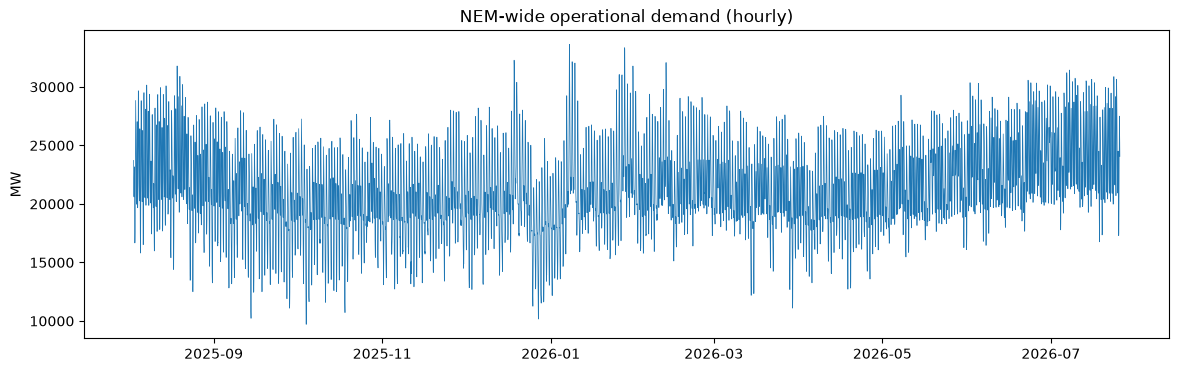

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df[target_col], linewidth=0.5)
ax.set_title("NEM-wide operational demand (hourly)")
ax.set_ylabel("MW")
plt.show()

## Per-region demand, most recent week\n\nThe NEM-wide total is the sum of these 5 regions.

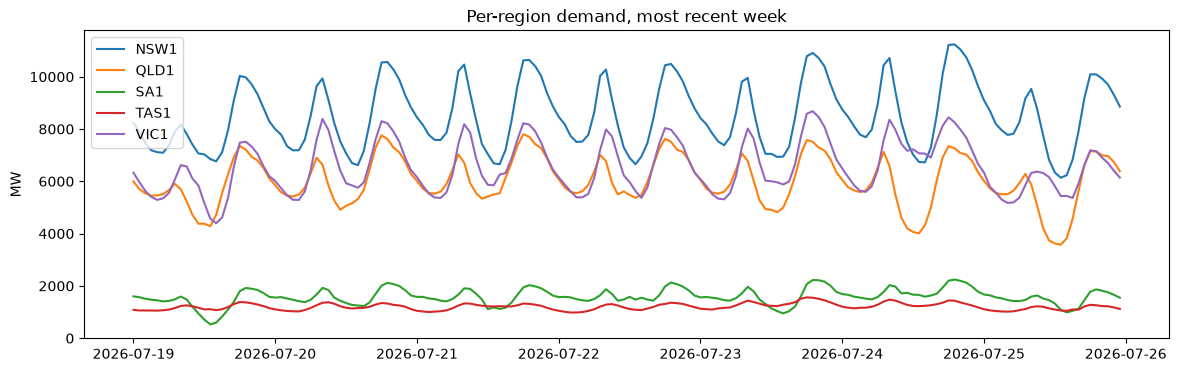

In [6]:
region_cols = [c for c in df.columns if c.startswith("demand_") and c != target_col]
last_week = df.iloc[-24 * 7:]

fig, ax = plt.subplots(figsize=(14, 4))
for col in region_cols:
    ax.plot(last_week.index, last_week[col], label=col.replace("demand_", "").upper())
ax.legend()
ax.set_title("Per-region demand, most recent week")
ax.set_ylabel("MW")
plt.show()

## Daily and weekly seasonality\n\nThe lag/rolling features in the next notebook exist to capture exactly these patterns.

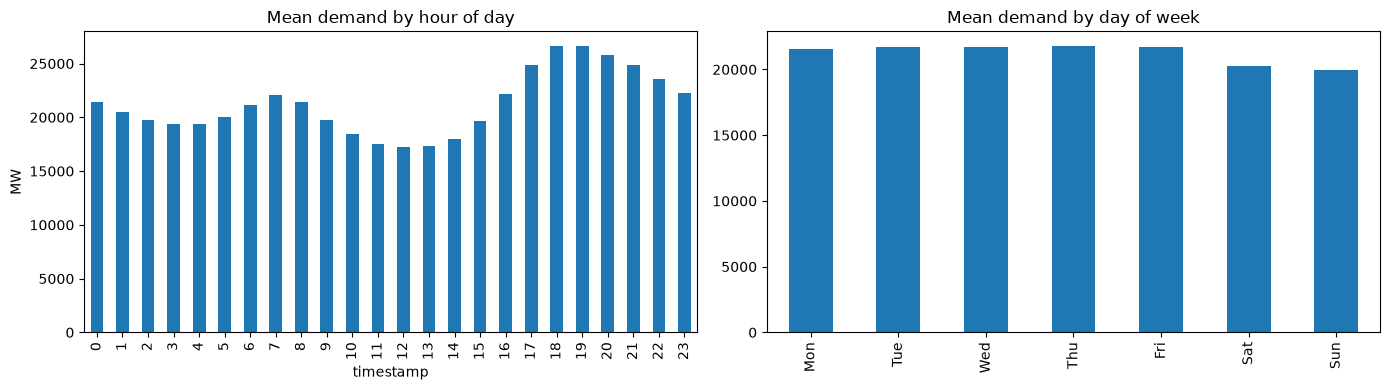

In [7]:
by_hour = df.groupby(df.index.hour)[target_col].mean()
by_dow = df.groupby(df.index.dayofweek)[target_col].mean()
by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
by_hour.plot(kind="bar", ax=axes[0], title="Mean demand by hour of day")
by_dow.plot(kind="bar", ax=axes[1], title="Mean demand by day of week")
axes[0].set_ylabel("MW")
plt.tight_layout()
plt.show()

## Why per-region columns are excluded from the model's features

`demand_nsw1` + `demand_qld1` + `demand_sa1` + `demand_tas1` + `demand_vic1` sums to
`demand` (the target) by construction - including them as predictors would be
near-perfect leakage, the same shape of bug as the old project's `temperature` column.
The correlations below make the risk concrete:

In [8]:
df[region_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)

demand_nsw1    0.933986
demand_vic1    0.846075
demand_qld1    0.760090
demand_sa1     0.733112
demand_tas1    0.639872
Name: demand, dtype: float64

## Train/val/test split\n\nChronological, not shuffled - a demand series is fundamentally sequential, and a random split would let the model train on hours that come *after* what it's being tested on.

In [9]:
train, val, test = chronological_split(df, config["split"]["train_ratio"], config["split"]["val_ratio"])
print(f"train: {len(train):>5} rows  {train.index.min()} -> {train.index.max()}")
print(f"val:   {len(val):>5} rows  {val.index.min()} -> {val.index.max()}")
print(f"test:  {len(test):>5} rows  {test.index.min()} -> {test.index.max()}")

train:  5997 rows  2025-08-03 00:00:00 -> 2026-04-09 20:00:00
val:    1285 rows  2026-04-09 21:00:00 -> 2026-06-02 09:00:00
test:   1286 rows  2026-06-02 10:00:00 -> 2026-07-25 23:00:00


## Feature engineering

Calendar (hour/day-of-week/month/weekend), lag (1, 2, 6, 24, 48, 168h), rolling
mean/std (3, 6, 12, 24, 168h window), and cyclical sin/cos encodings - all built by
`build_all_features()` in `src/features/build_features.py`, the single function
shared by training, live inference, and this notebook so none of the three can ever
compute features differently. Lags and rolling windows are shift-based (they never
see the current row's own value), which is what makes them safe to use as
predictors.

In [10]:
from src.features.build_features import build_all_features

features_df = build_all_features(df, target_col, config["features"]["lags"], config["features"]["rolling_windows"])
new_cols = [c for c in features_df.columns if c not in df.columns]
print(f"{len(new_cols)} engineered columns; first {config['features']['lags'][-1]} rows have warm-up NaNs (not enough history yet)")
features_df[new_cols].head(3)

26 engineered columns; first 168 rows have warm-up NaNs (not enough history yet)


,hour,day_of_week,month,is_weekend,demand_lag_1,demand_lag_2,demand_lag_6,demand_lag_24,demand_lag_48,demand_lag_168,...,demand_roll_mean_24,demand_roll_std_24,demand_roll_mean_168,demand_roll_std_168,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-08-03 00:00:00,0,6,8,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,1.000000,-0.781831,0.62349,-0.866025,-0.5
2025-08-03 01:00:00,1,6,8,1,23717.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.258819,0.965926,-0.781831,0.62349,-0.866025,-0.5
2025-08-03 02:00:00,2,6,8,1,22511.0,23717.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.500000,0.866025,-0.781831,0.62349,-0.866025,-0.5


Continues in **`02_modeling_and_evaluation.ipynb`**.